# Профилирование и оптимизация вычислений Dask

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Лекция "Dask"
* https://docs.dask.org/en/stable/diagnostics-local.html#profiler
* https://docs.dask.org/en/stable/diagnostics-local.html#progress-bar
* https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.broken_barh.html
* https://docs.python.org/3/library/stdtypes.html#str.rsplit
* https://docs.dask.org/en/stable/api.html#dask.datasets.make_people
* https://docs.dask.org/en/stable/scheduling.html
* https://distributed.dask.org/en/stable/client.html

## Задачи для совместного разбора

In [ ]:
!pip install dask==2023.3.2
!pip install distributed==2023.3.2

1\. Создайте массив целых чисел. Вычислите сумму элементов. Для демонстрации прогресса используйте ProgressBar. Модифицируйте ProgressBar.

In [ ]:
import dask.array as da
from dask.diagnostics import ProgressBar
import dask

a = da.random.randint(0, 100, size=(10000, 10000))

In [ ]:
%%time
s = a.mean()
s.compute()

CPU times: user 8.79 s, sys: 744 ms, total: 9.53 s
Wall time: 1.41 s


49.500777669

In [ ]:
with ProgressBar():
    r = s.compute()
r

[########################################] | 100% Completed | 1.55 sms


49.500777669

In [ ]:
# improt contextlib
import contextlib

In [ ]:
class MyProgressBar(ProgressBar):
    def __init__(self, char='#'):
        super().__init__()
        self.char = char

    def _draw_bar(self, frac, elapsed):
        from dask.utils import format_time

        bar = self.char * int(self._width * frac)
        percent = int(100 * frac)
        elapsed = format_time(elapsed)
        msg = "\r[{0:<{1}}] | {2}% Completed | {3}".format(
            bar, self._width, percent, elapsed
        )
        with contextlib.suppress(ValueError):
            if self._file is not None:
                self._file.write(msg)
                self._file.flush()

In [ ]:
with MyProgressBar(char='©'):
    r = s.compute()
r

[©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©©] | 100% Completed | 1.93 sms


49.500777669

2\. Отберите строки, сумма элементов которых является четной. Вычислите сумму полученного массива, используя различные планировщики.

In [ ]:
%%time
mask = a.sum(axis=1) % 2 == 0
b = a[mask].sum()
b.compute(scheduler='synchronous')

CPU times: user 674 ms, sys: 86.5 ms, total: 760 ms
Wall time: 759 ms


2438219086

In [ ]:
%%time
mask = a.sum(axis=1) % 2 == 0
b = a[mask].sum()
b.compute(scheduler='threads')

CPU times: user 870 ms, sys: 147 ms, total: 1.02 s
Wall time: 218 ms


2438219086

In [ ]:
%%time
mask = a.sum(axis=1) % 2 == 0
b = a[mask].sum()
b.compute(scheduler='processes')

CPU times: user 280 ms, sys: 1.87 s, total: 2.15 s
Wall time: 5.83 s


2438219086

3\. Изучите, как влияет вызов persist на скорость вычислений максимума и суммы элементов массива из предыдущей задачи.

In [ ]:
a = da.random.randint(0, 100, size=(100000, 10000))
mask = a.sum(axis=1) % 2 == 0
b = a[mask]

In [ ]:
m = b.max()
a = b.mean()

In [ ]:
%%time
m.compute(), a.compute()

CPU times: user 1.24 s, sys: 359 ms, total: 1.6 s
Wall time: 7.26 s


(99, 49.49924196366108)

In [ ]:
%%time
dask.compute(m, a)

CPU times: user 9.5 s, sys: 1.35 s, total: 10.8 s
Wall time: 1.63 s


(99, 49.500449081622435)

In [ ]:
%%time
a = da.random.randint(0, 100, size=(100000, 10000))
mask = a.sum(axis=1) % 2 == 0
b = a[mask].persist()

CPU times: user 9.26 s, sys: 3.86 s, total: 13.1 s
Wall time: 2.8 s


In [ ]:
m = b.max()
a = b.mean()

In [ ]:
%%time
m.compute(), a.compute()

CPU times: user 725 ms, sys: 4.51 s, total: 5.23 s
Wall time: 1.67 s


(99, 49.49954899628846)

4\. Изучите основные возможности Client на примере предыдущей задачи.

In [ ]:
from dask.distributed import Client
client = Client()
client

2023-04-17 11:15:19,680 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/bh/j3zgwyg51cn617yw2m26pg7c0000gn/T/dask-worker-space/worker-6fny6x32', purging
2023-04-17 11:15:19,680 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/bh/j3zgwyg51cn617yw2m26pg7c0000gn/T/dask-worker-space/worker-fo1dcl_e', purging
2023-04-17 11:15:19,680 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/bh/j3zgwyg51cn617yw2m26pg7c0000gn/T/dask-worker-space/worker-k66imt6p', purging
2023-04-17 11:15:19,680 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/bh/j3zgwyg51cn617yw2m26pg7c0000gn/T/dask-worker-space/worker-686dd3zs', purging
2023-04-17 11:15:19,681 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/bh/j3zgwyg51cn617yw2m26pg7c0000gn/T/dask-worker-space/worker-l4ukpsse', purging


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 8.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:61619,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 8.00 GiB
Comm: tcp://127.0.0.1:61630,Total threads: 2
Dashboard: http://127.0.0.1:61635/status,Memory: 2.00 GiB
Nanny: tcp://127.0.0.1:61622,


In [ ]:
%%time
m.compute()

CPU times: user 909 ms, sys: 177 ms, total: 1.09 s
Wall time: 3.56 s


99

In [ ]:
%%time
f = client.compute(m)
f

CPU times: user 17.1 ms, sys: 1.06 ms, total: 18.1 ms
Wall time: 17.5 ms


<Future: finished, type: numpy.int64, key: finalize-dd9a7457bcbf4c9d693a9ffed40e4174>

In [ ]:
print(1)

1


In [ ]:
%%time
f.result()

CPU times: user 3.11 ms, sys: 1.65 ms, total: 4.75 ms
Wall time: 4.65 ms


99

## Лабораторная работа 11

__При решении данных задач не подразумевается использования циклов или генераторов Python в ходе работы с пакетами `numpy`, `pandas` и `dask`, если в задании не сказано обратного. Решения задач, в которых для обработки массивов `numpy`, структур `pandas` или структур `dask` используются явные циклы (без согласования с преподавателем), могут быть признаны некорректными и не засчитаны.__

__Важно: задачи 1-7 решаются без запуска клиента `dask.distributed.Client`__

<p class="task" id="1"></p>

1\. Создайте массив из 1 млн. строк и 256 столбцов, заполненный числами из нормального распределения с $\mu=10$ и $\sigma=5$. При помощи метода `rechunk` сделайте так, чтобы данные были разбиты на сегменты по 250 тыс. строк.

Используя `dask.diagnostics.Profiler`, исследуйте процесс вычисления суммы элементов этого массива. Результат представьте в виде `pd.DataFrame` со столбцами: `key`, `start_time`, `end_time`, `worker_id`, `time_taken` и `task_type`. В поле `key` должны храниться строки - идентификаторы задач.

В поле `task_type` должны храниться строки - типы задач, которые можно извлечь из `key`. Например, для строки "normal-33a0474c5b5133263153dbd93d8fa610" категорией является "normal", а для строки "rechunk-merge-sum-290d08054ec62d2e1cd1c42b68f" - "rechunk-merge-sum".

Выведите на экран количество задач и количество уникальных типов этих задач

In [ ]:
a = da.random.normal(10, 5, size=(1e6, 256))
a = a.rechunk((2.5e5, 256))

In [ ]:
import pandas as pd
from dask.diagnostics import Profiler

with Profiler() as prof:
    a.sum().compute()
    prof_data = prof.results

def prof_data_to_df(prof_data):
    df = pd.DataFrame(prof_data)[['key', 'start_time', 'end_time', 'worker_id']]
    df['key'] = df['key'].apply(lambda x: x[0])
    df['time_taken'] = df['end_time'] - df['start_time']
    df['task_type'] = df['key'].apply(lambda x: "-".join(x.split('-')[:-1]))
    return df

df = prof_data_to_df(prof_data)

In [ ]:
df['key'].shape

(33,)

In [ ]:
df['task_type'].unique().shape

(6,)

<p class="task" id="2"></p>

2\. Профайлер `dask.diagnostics.Profiler` возвращает временные метки `start_time` и `end_time`, начиная с момента запуска ядра ноутбука. Напишите собственную версию профайлера `ProfilerWithInitialTimestamp`, который возвращает результаты замеров времени, начиная с момента запуска ячейки. Результат представьте в виде `pd.DataFrame` со столбцами: `key`, `start_time`, `end_time`, `worker_id`, `time_taken` и `task_type` аналогично заданию 1. Выведите на экран минимум и максимум по столбцу `start_time`.

In [ ]:
from timeit import default_timer

In [ ]:
class ProfilerWithInitialTimestamp(Profiler):
    def __init__(self):
        super().__init__()
        self.starting_time = default_timer()

    def _pretask(self, key, dsk, state):
        start = default_timer() - self.starting_time
        self._results[key] = (key, dsk[key], start)

    def _posttask(self, key, value, dsk, state, id):
        end = default_timer() - self.starting_time
        self._results[key] += (end, id)

In [ ]:
with ProfilerWithInitialTimestamp() as prof:
    a.sum().compute()
    prof_data = prof.results

new_df = prof_data_to_df(prof_data)
new_df['start_time'].min(), new_df['start_time'].max()

(0.002824332999807666, 1.1797804999996515)

<p class="task" id="3"></p>

3\. Визуализируйте процесс вычислений в виде горизонтальных столбчатых диаграмм с разрывами. По горизонтальной оси откладывается время, по вертикальной - номер задачи. Каждая задача располагается по вертикали на высоте, соответствующей своему номеру. Ширина столбца (по горизонтали) соответствует продолжительности выполнения задачи. Цвет столбца соответствует типу задачи. Каждый столбик должен иметь подпись, состояющую из нескольких первых символов идентификатора задачи.

Примерный вид итоговой визуализации:
![image.png](attachment:image.png)

In [ ]:
import matplotlib.pyplot as plt

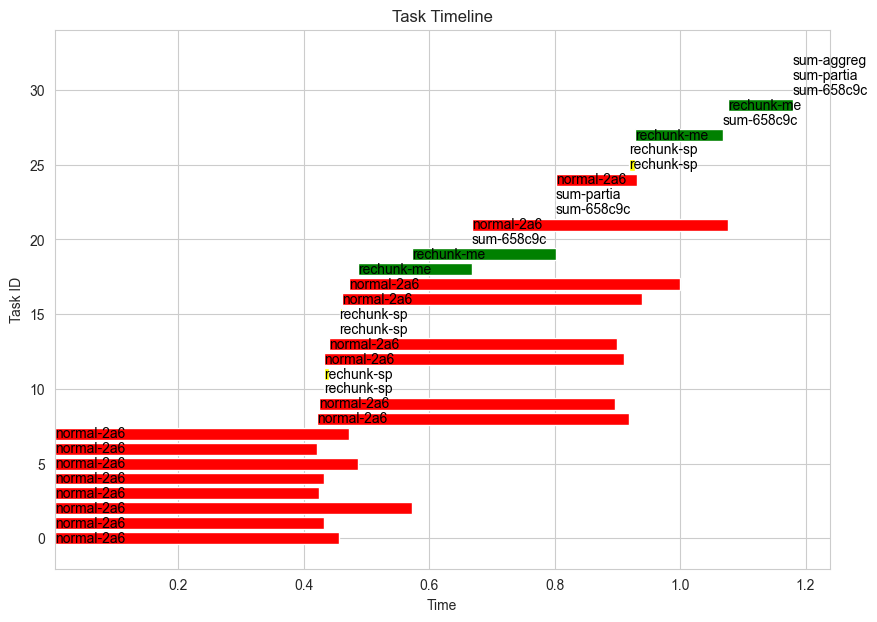

In [ ]:
def plot_timeline(df, figsize=(10, 7), color_dict=None):
    if color_dict is None:
        color_dict = {
            'normal': 'red',
            'rechunk-split': 'yellow',
            'rechunk-merge-sum': 'green',
            'sum': 'blue',
            'sum-partial': 'orange',
            'sum-aggregate': 'purple'
        }
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(
        y=df.index,
        left=df['start_time'],
        width=df['end_time'] - df['start_time'],
        color=df['task_type'].map(color_dict),
    )
    for text, x, y in zip(df['key'], df['start_time'], df.index):
        ax.text(x, y, text[:10], color='black', va='center', ha='left')
    ax.set_xlabel('Time')
    ax.set_ylabel('Task ID')
    ax.set_title('Task Timeline')
    return fig, ax

plot_timeline(new_df)
plt.show()

<p class="task" id="4"></p>

4\. Воспользовавшись функцией `dask.datasets.make_people`, сгенерируйте `Bag` со следующими характеристиками:

* кол-во сегментов - 25;
* кол-во элементов в одном сегменте - 20 тыс;
* seed=42

Посчитайте, сколько людей в полученном наборе данных проживают в городе "Las Vegas". Выведите это количество на экран. Для демонстрации прогресса вычислений воспользуйтесь `dask.diagnostics.ProgressBar`.

In [ ]:
!pip3 install mimesis

Defaulting to user installation because normal site-packages is not writeable
  Using cached mimesis-8.0.0-py3-none-any.whl (4.4 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 kB 610.1 kB/s eta 0:00:00a 0:00:01
  Using cached pytest_cov-4.0.0-py3-none-any.whl (21 kB)
  Using cached pytest-7.3.1-py3-none-any.whl (320 kB)
  Using cached pluggy-1.0.0-py2.py3-none-any.whl (13 kB)
  Using cached iniconfig-2.0.0-py3-none-any.whl (5.9 kB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.0.1 -> 23.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [ ]:
from dask.datasets import make_people
import dask.bag as db

b = db.from_sequence(make_people(25, 20_000, seed=42), npartitions=25)

In [ ]:
from dask.diagnostics import ProgressBar

people_LV = b.filter(lambda x: x['address']['city'] == 'Las Vegas')

with ProgressBar():
    print(people_LV.count().compute())

[########################################] | 100% Completed | 2.38 ss
288


<p class="task" id="5"></p>

5\. Воспользовавшись `Bag`, полученном в задании 4, посчитайте и выведите на экран, сколько людей в полученном наборе данных проживают в городе "Las Vegas", используя различные планировщики:
* планировщик на потоках;
* планировщик на процессах;
* синхронный планировщик (1 поток).

При выполнении вычислений используйте `ProgressBar` для замера времени.

Сделайте вывод в виде текстового комментария.

In [ ]:
with ProgressBar():
    print(people_LV.count().compute(scheduler='threads'))

[########################################] | 100% Completed | 1.45 ss
288


In [ ]:
with ProgressBar():
    print(people_LV.count().compute(scheduler='processes'))

[########################################] | 100% Completed | 2.34 ss
288


In [ ]:
with ProgressBar():
    print(people_LV.count().compute(scheduler='synchronous'))

[########################################] | 100% Completed | 1.46 ss
288


*threads* - быстрее всего, *processes* - дольше, тк затрачивает много времени на создание процессов, *synchronous* - оказался приблизительно таким же как и *processes*

<p class="task" id="6"></p>

6\. Воспользовавшись `da.random.RandomState`, укажите зерно ГПСЧ, равное 42, и создайте массив `arr` из 1 млн. строк и 312 столбцов, заполненный числами из стандартного нормального распределения. Создайте массив `arr_masked`, содержащий строки из массива `arr`, для которых целая часть модуля суммы элементов нацело делится на 5.

Вычислите и выведите на экран сумму элементов массива и корень из суммы квадратов всех элементов массива. Выведите на экран эти значения и суммарное время вычисления двух этих значений.

In [ ]:
import dask.array as da

r = da.random.RandomState(seed=42)
arr = r.normal(size=(1e6, 312))

mask = da.abs(arr.sum(axis=1)).astype(int)
arr_masked = arr[mask]

/Users/macbook/Library/Python/3.9/lib/python/site-packages/dask/array/slicing.py:1084: PerformanceWarning: Increasing number of chunks by factor of 19
  p = blockwise(


In [ ]:
sum_of_ma = arr_masked.sum()
sqrt_sum_of_sqr_of_ma = da.sqrt((arr_masked ** 2).sum())

In [ ]:
%%time
sum_of_ma.compute(), sqrt_sum_of_sqr_of_ma.compute()

CPU times: user 17.3 s, sys: 11.8 s, total: 29.1 s
Wall time: 14.9 s


(-1257719.1218386847, 17686.271206933594)

<p class="task" id="7"></p>

7\. Повторите решение задачи 6, предрассчитав значения `arr_masked` при помощи метода `persist`. Сравните время выполнения двух решений. Выведите на экран время выполнения вызова `arr_masked.compute()`.

In [ ]:
r = da.random.RandomState(seed=42)
arr = r.normal(size=(1e6, 312))

mask = da.abs(arr.sum(axis=1)).astype(int)
arr_masked = arr[mask].persist()

/Users/macbook/Library/Python/3.9/lib/python/site-packages/dask/array/slicing.py:1084: PerformanceWarning: Increasing number of chunks by factor of 19
  p = blockwise(


In [ ]:
sum_of_ma = arr_masked.sum()
sqrt_sum_of_sqr_of_ma = da.sqrt((arr_masked ** 2).sum())

In [ ]:
%%time
sum_of_ma.compute(), sqrt_sum_of_sqr_of_ma.compute()

CPU times: user 949 ms, sys: 996 ms, total: 1.95 s
Wall time: 382 ms


(-1257719.1218386847, 17686.271206933594)

In [ ]:
%%time
arr_masked.compute()

CPU times: user 112 ms, sys: 1.51 s, total: 1.62 s
Wall time: 11.5 s


array([[-0.42185471,  1.26482239,  0.85214746, ..., -0.36706461,
        -3.36493775,  0.02240007],
       [ 0.03021285,  0.0467127 ,  0.59565501, ...,  0.4678925 ,
         1.96942228, -1.29134531],
       [-1.49226571,  0.0309281 ,  1.09384155, ..., -0.7391266 ,
        -0.72679022, -0.34055384],
       ...,
       [ 0.42808418, -0.29832767, -1.26709558, ..., -0.55774968,
         0.28500715, -0.34864556],
       [-2.22922763, -0.23650042,  0.60668172, ..., -0.13448707,
        -0.35879518,  0.97054159],
       [-0.42938349,  0.64227945,  0.22879528, ...,  0.05544971,
        -0.46384387,  1.46690874]])

<p class="task" id="8"></p>

8\. Запустите `dask.distributed.Client`. Воспользовавшись `Bag`, полученном в задании 4, посчитайте, сколько людей в полученном наборе данных проживают в городе "Las Vegas". Проведите расчеты двумя способами:
* с использованием блокирующего вызова `Bag.compute`
* с использованием неблокирующего вызова `Client.compute`

Используя дашборд, который предоставляет `dask.distributed.Client`, сделайте и вставьте в ноутбук скриншоты
* хода процесса вычислений (вкладка Status)
* графа вычислений (вкладка Graph)

In [ ]:
from dask.distributed import Client

client = Client()
client

2023-04-21 17:06:40,925 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/bh/j3zgwyg51cn617yw2m26pg7c0000gn/T/dask-worker-space/worker-pp42o54n', purging
2023-04-21 17:06:40,925 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/bh/j3zgwyg51cn617yw2m26pg7c0000gn/T/dask-worker-space/worker-rf8rcpza', purging
2023-04-21 17:06:40,926 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/bh/j3zgwyg51cn617yw2m26pg7c0000gn/T/dask-worker-space/worker-dxdfkzoj', purging
2023-04-21 17:06:40,926 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/bh/j3zgwyg51cn617yw2m26pg7c0000gn/T/dask-worker-space/worker-f8m9e6i2', purging


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 8.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:58176,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 8.00 GiB
Comm: tcp://127.0.0.1:58188,Total threads: 2
Dashboard: http://127.0.0.1:58192/status,Memory: 2.00 GiB
Nanny: tcp://127.0.0.1:58179,


In [ ]:
people_LV = b.filter(lambda x: x['address']['city'] == 'Las Vegas')

people_LV.count().compute()

288

In [ ]:
res = client.compute(people_LV.count())

In [ ]:
res.result()

288

![image.png](attachment:image.png)

![image.png](attachment:image.png)

<p class="task" id="9"></p>

9\. Запустите `dask.distributed.Client`. Воспользовавшись `Bag`, полученном в задании 4, создайте `Bag` `young_people`, содержащий записи о людях, которым не более 50 лет. Вычислите и выведите на экран должность (`occupation`), которая встречается чаще всего, а также количество уникальных имен (имя хранится элементе с индексом 1 кортежа под ключом `name`). Выведите на экран эти значения и суммарное время вычисления двух этих значений.

In [ ]:
young_people = b.filter(lambda x: x['age'] <= 50)

most_popular_occupation = young_people.pluck('occupation').frequencies().topk(1, key=1)
unique_first_names = young_people.pluck('name').map(lambda x: x[1]).distinct()

In [ ]:
%%time
most_popular_occupation.compute()[0][0], unique_first_names.count().compute()

CPU times: user 8.91 s, sys: 349 ms, total: 9.26 s
Wall time: 10.4 s


('Medical Officer', 1000)

<p class="task" id="10"></p>

10\. Повторите решение задачи 9, предрассчитав значения `young_people` при помощи метода `persist`. Обратите внимание, что при запущенном `Client` метод `Bag.persist` стал неблокирующим. Отследите в дашборде (сделайте и вставьте скриншот) процедуру выполнения метода `persist`. После того, как он закончится, приступайте к дальнейшим вычислениям.

Сравните время выполнения двух решений.

In [ ]:
young_people = b.filter(lambda x: x['age'] <= 50).persist()

![image.png](attachment:image.png)

In [ ]:
most_popular_occupation = young_people.pluck('occupation').frequencies().topk(1, key=1)
unique_first_names = young_people.pluck('name').map(lambda x: x[1]).distinct()

In [ ]:
%%time
most_popular_occupation.compute()[0][0], unique_first_names.count().compute()

CPU times: user 4.82 s, sys: 384 ms, total: 5.2 s
Wall time: 6.16 s


('Medical Officer', 1000)

In [ ]:
b.take(2)

({'age': 29,
  'name': ('Londa', 'Miranda'),
  'occupation': 'Thermal Insulator',
  'telephone': '472-418-7730',
  'address': {'address': '429 Nelson Manor', 'city': 'Ponca City'},
  'credit-card': {'number': '4378 5985 0614 7635',
   'expiration-date': '01/21'}},
 {'age': 33,
  'name': ('Allyn', 'Simon'),
  'occupation': 'Tour Guide',
  'telephone': '(519) 787-0795',
  'address': {'address': '1038 Nevada Bayou', 'city': 'Leander'},
  'credit-card': {'number': '3774 109479 08972', 'expiration-date': '02/24'}})